In [ ]:
import tensorflow as tf 
from tensorflow import keras 
from tensorflow.keras import layers, applications, regularizers 
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.utils import class_weight 

In [6]:
train_dir = r"C:\Users\Yaswanth\Downloads\diatom-classification\dataset\train"
val_dir   = r"C:\Users\Yaswanth\Downloads\diatom-classification\dataset\val"
test_dir  = r"C:\Users\Yaswanth\Downloads\diatom-classification\dataset\test"

In [7]:
# 2. Load Dataset with Augmentation 
# --------------------------- 
BATCH_SIZE = 32 
IMG_SIZE = (128, 128) 
 
train_datagen = keras.preprocessing.image.ImageDataGenerator( 
    rescale=1./255, 
    rotation_range=30, 
    width_shift_range=0.3, 
    height_shift_range=0.3, 
    shear_range=0.3, 
    zoom_range=0.3, 
    horizontal_flip=True, 
    fill_mode="nearest" 
) 
 
val_datagen = keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

In [8]:
train_ds = train_datagen.flow_from_directory( 
    train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='sparse' 
) 
val_ds = val_datagen.flow_from_directory( 
    val_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='sparse' 
) 
test_ds = val_datagen.flow_from_directory( 
    test_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='sparse', 
shuffle=False 
)

Found 14729 images belonging to 10 classes.
Found 4906 images belonging to 10 classes.
Found 4948 images belonging to 10 classes.


In [9]:
num_classes = len(train_ds.class_indices) 
print("Number of Classes:", num_classes) 

Number of Classes: 10


In [10]:
# --------------------------- 
all_labels = np.concatenate([train_ds.classes]) 
cw = class_weight.compute_class_weight('balanced', classes=np.unique(all_labels), 
y=all_labels) 
class_weights = {i: cw[i] for i in range(len(cw))} 
print("Class Weights:", class_weights) 

Class Weights: {0: 0.8538550724637681, 1: 0.8932080048514252, 2: 0.7923076923076923, 3: 1.346343692870201, 4: 0.6964066193853428, 5: 1.0565997130559541, 6: 1.0798387096774194, 7: 1.301148409893993, 8: 1.194566098945661, 9: 1.2653780068728522}


In [11]:
#--------------------------- 
# 4. Model with ResNet50 (Fine-tuned) 
# --------------------------- 
base_model = applications.ResNet50(include_top=False, input_shape=IMG_SIZE + (3,)) 
base_model.trainable = False  # Freeze base model 
 
model = keras.Sequential([ 
    base_model, 
    layers.GlobalAveragePooling2D(), 
    layers.BatchNormalization(), 
    layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(1e-4)), 
    layers.Dropout(0.4), 
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4)), 
    layers.Dropout(0.3), 
    layers.Dense(num_classes, activation='softmax') 
]) 
 
model.compile( 
    optimizer=keras.optimizers.Adam(learning_rate=1e-4), 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy'] 
) 
model.summary() 

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50 (Functional)       (None, 4, 4, 2048)        23587712  
                                                                 
 global_average_pooling2d (G  (None, 2048)             0         
 lobalAveragePooling2D)                                          
                                                                 
 batch_normalization (BatchN  (None, 2048)             8192      
 ormalization)                                                   
                                                                 
 dense (Dense)               (None, 512)               1049088   
                                                                 
 dropout (Dropout)           (None, 512)               0         
                                                                 
 dense_1 (Dense)             (None, 256)               1

In [12]:
# --------------------------- 
# 5. Callbacks (LR Reduction + Early Stopping) 
# --------------------------- 
callbacks = [ 
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, 
restore_best_weights=True),    
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, 
min_lr=1e-6), 
    keras.callbacks.ModelCheckpoint("cnn_model_V5.keras", save_best_only=True) 
] 

In [13]:
#--------------------------- 
# 6. Train Model (First Stage) 
# --------------------------- 
history = model.fit( 
    train_ds, 
    validation_data=val_ds, 
    epochs=20, 
    class_weight=class_weights, 
    callbacks=callbacks 
) 

Epoch 1/20
461/461 [==============================] - 373s 801ms/step - loss: 2.1541 - accuracy: 0.2618 - val_loss: 1.9751 - val_accuracy: 0.3084 - lr: 1.0000e-04
Epoch 2/20
461/461 [==============================] - 261s 567ms/step - loss: 1.9483 - accuracy: 0.3118 - val_loss: 1.7918 - val_accuracy: 0.3836 - lr: 1.0000e-04
Epoch 3/20
461/461 [==============================] - 256s 555ms/step - loss: 1.8740 - accuracy: 0.3361 - val_loss: 1.7612 - val_accuracy: 0.3897 - lr: 1.0000e-04
Epoch 4/20
461/461 [==============================] - 788s 2s/step - loss: 1.8527 - accuracy: 0.3377 - val_loss: 1.7336 - val_accuracy: 0.4044 - lr: 1.0000e-04
Epoch 5/20
461/461 [==============================] - 258s 559ms/step - loss: 1.8299 - accuracy: 0.3518 - val_loss: 1.7204 - val_accuracy: 0.4048 - lr: 1.0000e-04
Epoch 6/20
461/461 [==============================] - 257s 557ms/step - loss: 1.8030 - accuracy: 0.3587 - val_loss: 1.7111 - val_accuracy: 0.4115 - lr: 1.0000e-04
Epoch 7/20
461/461 [=====

In [14]:
# --------------------------- 
# 7. Fine-Tune (Unfreeze Top Layers) 
# --------------------------- 
base_model.trainable = True  # Unfreeze for fine-tuning 
model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-5),  # Lower LR for finetuning 
              loss='sparse_categorical_crossentropy', metrics=['accuracy']) 
 
history_fine = model.fit( 
    train_ds, 
    validation_data=val_ds,  
    epochs=20, 
    class_weight=class_weights, 
    callbacks=callbacks 
) 

Epoch 1/20
461/461 [==============================] - 1009s 2s/step - loss: 2.0737 - accuracy: 0.4311 - val_loss: 11.8656 - val_accuracy: 0.1333 - lr: 1.0000e-05
Epoch 2/20
461/461 [==============================] - 993s 2s/step - loss: 1.1714 - accuracy: 0.6087 - val_loss: 2.7240 - val_accuracy: 0.3575 - lr: 1.0000e-05
Epoch 3/20
461/461 [==============================] - 988s 2s/step - loss: 0.8995 - accuracy: 0.6888 - val_loss: 0.8327 - val_accuracy: 0.7234 - lr: 1.0000e-05
Epoch 4/20
461/461 [==============================] - 1008s 2s/step - loss: 0.7752 - accuracy: 0.7320 - val_loss: 0.7066 - val_accuracy: 0.7568 - lr: 1.0000e-05
Epoch 5/20
461/461 [==============================] - 996s 2s/step - loss: 0.6653 - accuracy: 0.7669 - val_loss: 0.8251 - val_accuracy: 0.7297 - lr: 1.0000e-05
Epoch 6/20
461/461 [==============================] - 997s 2s/step - loss: 0.5968 - accuracy: 0.7878 - val_loss: 0.5287 - val_accuracy: 0.8088 - lr: 1.0000e-05
Epoch 7/20
461/461 [=================

155/155 [==============================] - 83s 537ms/step - loss: 0.3502 - accuracy: 0.8846
Test Accuracy: 0.8845998644828796


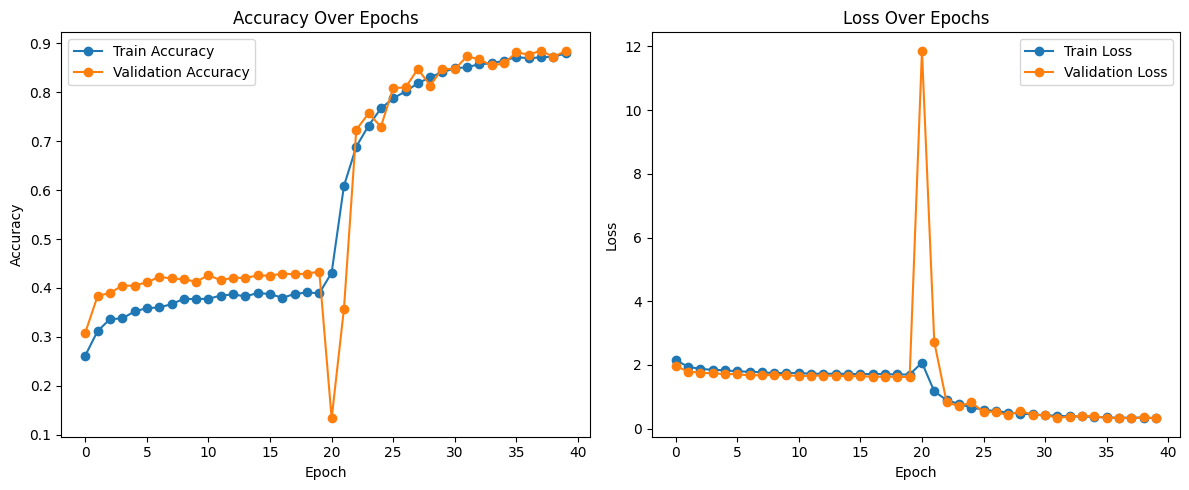

In [15]:
# --------------------------- 
# 8. Evaluate & Plot Results 
# --------------------------- 
test_loss, test_acc = model.evaluate(test_ds) 
print("Test Accuracy:", test_acc) 
 
# Plot Loss and Accuracy 
plt.figure(figsize=(12, 5)) 
plt.subplot(1, 2, 1) 
plt.plot(history.history['accuracy'] + history_fine.history['accuracy'], label='Train Accuracy', marker='o') 
plt.plot(history.history['val_accuracy'] + history_fine.history['val_accuracy'], 
label='Validation Accuracy', marker='o') 
plt.xlabel("Epoch") 
plt.ylabel("Accuracy") 
plt.title("Accuracy Over Epochs") 
plt.legend() 

plt.subplot(1, 2, 2) 
plt.plot(history.history['loss'] + history_fine.history['loss'], label='Train Loss', 
marker='o') 
plt.plot(history.history['val_loss'] + history_fine.history['val_loss'], label='Validation Loss', marker='o') 
plt.xlabel("Epoch") 
plt.ylabel("Loss") 
plt.title("Loss Over Epochs") 
plt.legend() 
 
plt.tight_layout() 
plt.show() 

In [16]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50 (Functional)       (None, 4, 4, 2048)        23587712  
                                                                 
 global_average_pooling2d (G  (None, 2048)             0         
 lobalAveragePooling2D)                                          
                                                                 
 batch_normalization (BatchN  (None, 2048)             8192      
 ormalization)                                                   
                                                                 
 dense (Dense)               (None, 512)               1049088   
                                                                 
 dropout (Dropout)           (None, 512)               0         
                                                                 
 dense_1 (Dense)             (None, 256)               1

In [17]:
model.save("diatom_model.keras")